K-Means in Pyton

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

Creo il dataset

In [20]:
wine=load_wine() #dataset
X,y=wine.data, wine.target #X=matrice delle feature y= classi dei vini, sono le label
feature_names=wine.feature_names #nomi delle colonne

(in k-means y non viene utilizzato, perchè k-means non è usato per addestrare. Quindi y serve solo se alla fine si vuole confrontare i cluster con le classi vere, altrimenti potrebbe non essere caricaoto y)

Standarizzo tutte le feature (X)
in modo da rendere tutte le colonne confrontabili

In [21]:
scaler=StandardScaler()
X_std=scaler.fit_transform(X)

provo K-Means con valori diversi di k per trovare il migliore  

In [22]:
#preparazione del metodo del gomito
wcss=[] #crea lista vuota (più i punti sono vicini al loro centroide, più WCSS è bassa)
k_values=range(1,11)  #crea i valori k da 1 a 10 (so che wine ha 10 feature)
for k in k_values:  #per ogni k (da 1 a 10) provo il kmeans
    kmeans=KMeans(n_clusters=k,init='k-means++',random_state=42) #creo il metodo kmeans con k cluster
    kmeans.fit(X_std) #addestro il modello
    wcss.append(kmeans.inertia_)

c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

faccio il plot per capire il k migliore con il metodo del 'gomito'
(mi aspetto una curva decrescente, perchè più cluster k metto, più ogni punto ha un centro vicino,
devi guardare dove il decrescere, decresce meno, quello è il gomito, cioè il punto dove la discesa 'forte' si smorza)

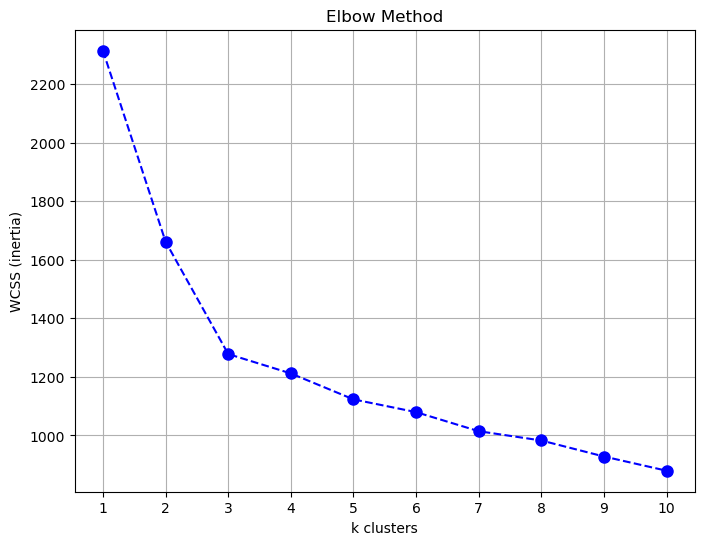

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(k_values,wcss,"o--",color="blue",markersize=8) #x=k y=wcss
plt.xlabel("k clusters")
plt.ylabel("WCSS (inertia)")
plt.xticks(k_values)
plt.title("Elbow Method")
plt.grid(True)
plt.show()

Rifaccio k-Means con il k=3 ottimale trovato

Il punto di flesso è k=3.
Da k=3 la funzione decresce con un altro andamento

In [ ]:
k=3
kmeans=KMeans(n_clusters=k,init="k-means++",random_state=42)
clusters=kmeans.fit_predict(X_std)

centroids=kmeans.cluster_centers_ #salvo i centroidi finali (avendo 13 feature nel dataset originale, ogni centroide ha 13 valori)
iter=kmeans.n_iter_  #numero di iterazoini servite per convergere

print(f"Iteration: \t{iter}")
print(f"Centroidi: \n{centroids}")


Iteration: 	7
Centroidi: 
[[-0.92607185 -0.39404154 -0.49451676  0.17060184 -0.49171185 -0.07598265
   0.02081257 -0.03353357  0.0582655  -0.90191402  0.46180361  0.27076419
  -0.75384618]
 [ 0.16490746  0.87154706  0.18689833  0.52436746 -0.07547277 -0.97933029
  -1.21524764  0.72606354 -0.77970639  0.94153874 -1.16478865 -1.29241163
  -0.40708796]
 [ 0.83523208 -0.30380968  0.36470604 -0.61019129  0.5775868   0.88523736
   0.97781956 -0.56208965  0.58028658  0.17106348  0.47398365  0.77924711
   1.12518529]]


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


utilizzo la PCA per rappresentare i dati

In [9]:
pca=PCA(n_components=2,random_state=42)
X_pca=pca.fit_transform(X_std)


plot

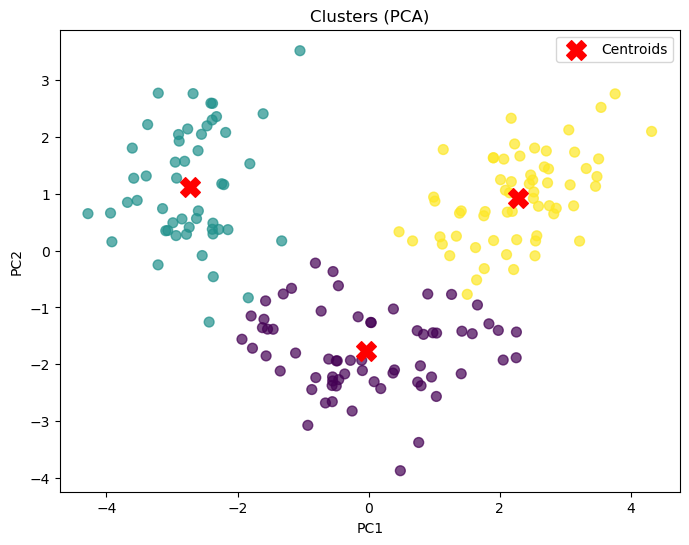

In [12]:

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=clusters,cmap="viridis",s=50,alpha=0.7)
plt.scatter(
    pca.transform(centroids)[:,0],
    pca.transform(centroids)[:,1],
    c="red",
    s=200,
    marker="X",
    label="Centroids",
)
plt.title("Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

K-Means ha lavorato molto bene perchè i 3 cluster sono ben separati tra di loro

Vedere le label originali

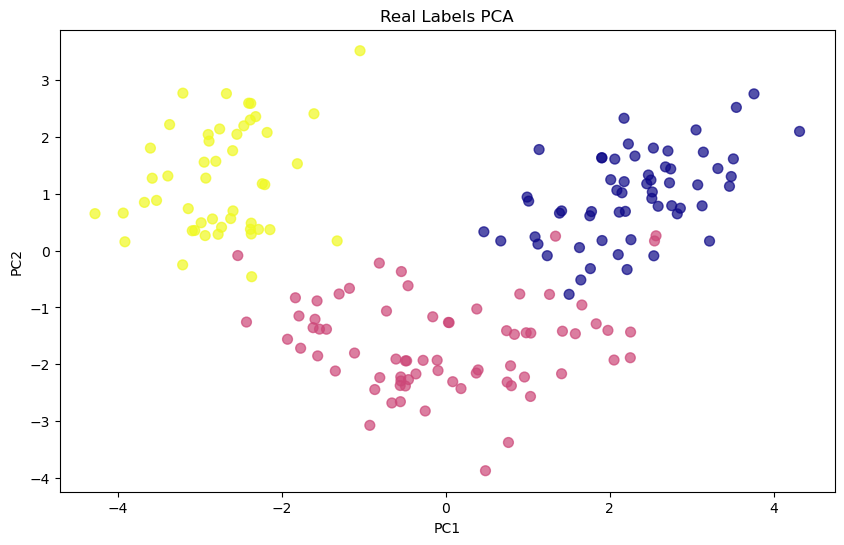

In [13]:
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=y,cmap="plasma",s=50,alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Real Labels PCA")
plt.show()